In [ ]:
!pip install matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv(r"C:\Users\tanwa\Downloads\archive\phishing_email.csv") 

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (82797, 2)
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...    0.0
1  nom actual vols 24 th forwarded sabrae zajac h...    0.0
2  enron actuals march 30 april 1 201 estimated a...    0.0
3  hpl nom may 30 2001 see attached file hplno 53...    0.0
4  hpl nom june 1 2001 see attached file hplno 60...    0.0


In [4]:
print(df.columns)

Index(['text_combined', 'label'], dtype='object')


In [5]:
print("Columns:", df.columns)
df['EmailText'] = df['text_combined']   

if df['label'].dtype == 'object':  
    df['label'] = df['label'].map({'phishing': 1, 'genuine': 0})

print(df.head())

Columns: Index(['text_combined', 'label'], dtype='object')
                                       text_combined  label  \
0  hpl nom may 25 2001 see attached file hplno 52...    0.0   
1  nom actual vols 24 th forwarded sabrae zajac h...    0.0   
2  enron actuals march 30 april 1 201 estimated a...    0.0   
3  hpl nom may 30 2001 see attached file hplno 53...    0.0   
4  hpl nom june 1 2001 see attached file hplno 60...    0.0   

                                           EmailText  
0  hpl nom may 25 2001 see attached file hplno 52...  
1  nom actual vols 24 th forwarded sabrae zajac h...  
2  enron actuals march 30 april 1 201 estimated a...  
3  hpl nom may 30 2001 see attached file hplno 53...  
4  hpl nom june 1 2001 see attached file hplno 60...  


In [6]:

df = df.dropna(subset=['label'])
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)


In [7]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=1000))
])

In [8]:
pipeline.fit(train_df['EmailText'], train_df['label'])
print("✅ Model training complete")

✅ Model training complete


In [10]:
y_pred = pipeline.predict(test_df['EmailText'])

In [11]:
acc = accuracy_score(test_df['label'], y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")

Model Accuracy: 98.65%


In [12]:
print("\nClassification Report:")
print(classification_report(test_df['label'], y_pred, target_names=["Genuine","Phishing"]))



Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.98      0.99      7919
    Phishing       0.99      0.99      0.99      8579

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



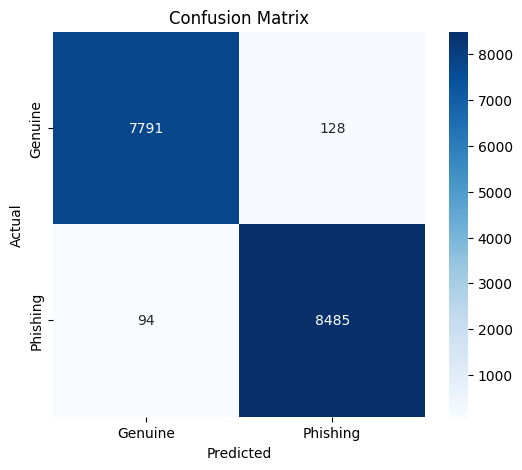

In [13]:
cm = confusion_matrix(test_df['label'], y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Genuine","Phishing"], yticklabels=["Genuine","Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
pip install gradio


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(r"C:\Users\tanwa\Downloads\archive\phishing_email.csv")  
df['EmailText'] = df['text_combined']    # rename for consistency
df = df.dropna(subset=['label'])  # drop rows without labels

# Train/Test Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# TF-IDF + Logistic Regression Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=20000)),
    ('clf', LogisticRegression(max_iter=1000))
])
pipeline.fit(train_df['EmailText'], train_df['label'])

# Prediction Function
def predict_email(text):
    pred = pipeline.predict([text])[0]
    return "⚠️ Phishing Email" if pred == 1 else "✅ Genuine Email"

# Metrics Function
def show_metrics():
    preds = pipeline.predict(test_df['EmailText'])
    report = classification_report(test_df['label'], preds, output_dict=True)

    # Confusion Matrix plot
    cm = confusion_matrix(test_df['label'], preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Genuine','Phishing'],
                yticklabels=['Genuine','Phishing'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("cm.png")
    plt.close()

    # Handle both classes safely
    precision_0 = report['0']['precision']*100 if '0' in report else 0
    recall_0 = report['0']['recall']*100 if '0' in report else 0
    f1_0 = report['0']['f1-score']*100 if '0' in report else 0

    precision_1 = report['1']['precision']*100 if '1' in report else 0
    recall_1 = report['1']['recall']*100 if '1' in report else 0
    f1_1 = report['1']['f1-score']*100 if '1' in report else 0

    table_data = [
        ["Logistic Regression (Genuine Class - 0)", 
         f"{report['accuracy']*100:.2f}",
         f"{precision_0:.2f}",
         f"{recall_0:.2f}",
         f"{f1_0:.2f}",
         "phishing_email.csv"],

        ["Logistic Regression (Phishing Class - 1)", 
         f"{report['accuracy']*100:.2f}",
         f"{precision_1:.2f}",
         f"{recall_1:.2f}",
         f"{f1_1:.2f}",
         "phishing_email.csv"]
    ]

    return table_data, "cm.png"

# Gradio UI
with gr.Blocks() as demo:
    gr.Markdown("## 📧 Phishing Email Detector (Logistic Regression)")

    with gr.Tab("🔍 Predict Email"):
        email_input = gr.Textbox(label="Enter Email Text", placeholder="Paste email content here...")
        pred_output = gr.Label(label="Prediction")
        email_input.submit(predict_email, inputs=email_input, outputs=pred_output)

    with gr.Tab("📊 Model Metrics"):
        metrics_table = gr.Dataframe(headers=["Algorithm","Accuracy (%)","Precision (%)","Recall (%)","F1 Score (%)","Dataset"],
                                     interactive=False)
        cm_image = gr.Image(label="Confusion Matrix")
        btn_metrics = gr.Button("Show Model Metrics")
        btn_metrics.click(show_metrics, outputs=[metrics_table, cm_image])

# Launch locally (open in browser)
demo.launch()


C:\Users\tanwa\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
